<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/lab%2019/Lab_19_Tree_Based_Models_%E2%80%94_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 19: Tree-Based Models — Random Forests
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Compare a single decision tree, Ridge regression, and Random Forest on the same dataset
- Tune Random Forest hyperparameters via cross-validation
- Extract and interpret feature importance (MDI and permutation)
- Apply the Ch 18 evaluation toolkit (confusion matrix, AUC) to a RF classifier

**Dataset:** California Housing (sklearn) — recurring thread from Ch 4, 12-16

**Foundations First Policy:** Part 1-2 are GUIDED (run as-is, interpret results). Part 3 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

---

## Setup

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load California Housing data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load California Housing (you've seen this dataset since Ch 4)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} observations')
print(f'Features: {list(X.columns)}')

Training set: 16512 observations, 8 features
Test set: 4128 observations
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Part 1: Decision Tree vs. Random Forest vs. Ridge (GUIDED — 10 min)

We compare three models on the same data. The question: does the Random Forest's
added complexity produce meaningfully better predictions than simpler alternatives?

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Train and compare Decision Tree, Ridge, and RF
# -----------------------------------------------------------

# 1. Unrestricted Decision Tree (high variance, low bias)
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

# 2. Ridge Regression (Ch 16 callback — stable but linear)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# 3. Random Forest (100 trees, default settings)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Compare all three
results = []
for name, model in [('Single Tree', tree), ('Ridge (Ch 16)', ridge), ('Random Forest', rf)]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R\u00b2': r2_score(y_train, train_pred),
        'Test R\u00b2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

               Train RMSE  Test RMSE  Train R²  Test R²
Model                                                  
Single Tree        0.0000     0.7037    1.0000   0.6221
Ridge (Ch 16)      0.7197     0.7455    0.6126   0.5759
Random Forest      0.1880     0.5053    0.9736   0.8051


### Interpretation Questions (answer in a markdown cell below)

1. Which model has the largest gap between Train R² and Test R²? What does this tell you about its variance?

The Single Tree has the largest gap. Train R² of 1.0000 vs Test R² of 0.6221. This indicates severe overfitting (high variance): the model memorized the training data perfectly but failed to generalize.

2. The Random Forest's Test R² is substantially higher than Ridge. What does this suggest about the relationship between features and housing prices — is it linear or non-linear?

Random Forest's substantially higher Test R² (0.8051 vs Ridge's 0.5759) suggests the relationship between features and housing prices is non-linear. Ridge, being a linear model, can't capture those patterns, while the tree-based ensemble can.

3. **Callback to Ch 15:** Where does each model sit on the bias-variance U-curve?

The Single Tree sits at the high-variance end of the U-curve (low bias on training, high error on test). Ridge sits closer to the high-bias end (stable but underfitting due to linearity). Random Forest lands near the optimal middle, balancing bias and variance through bagging and averaging across 100 trees.

*Your answers here:*

1.
2.
3.

## Part 2: Feature Importance — MDI vs. Permutation (GUIDED — 10 min)

Random Forests tell us which features matter most for prediction.
But remember: **predictive importance ≠ causal importance.**

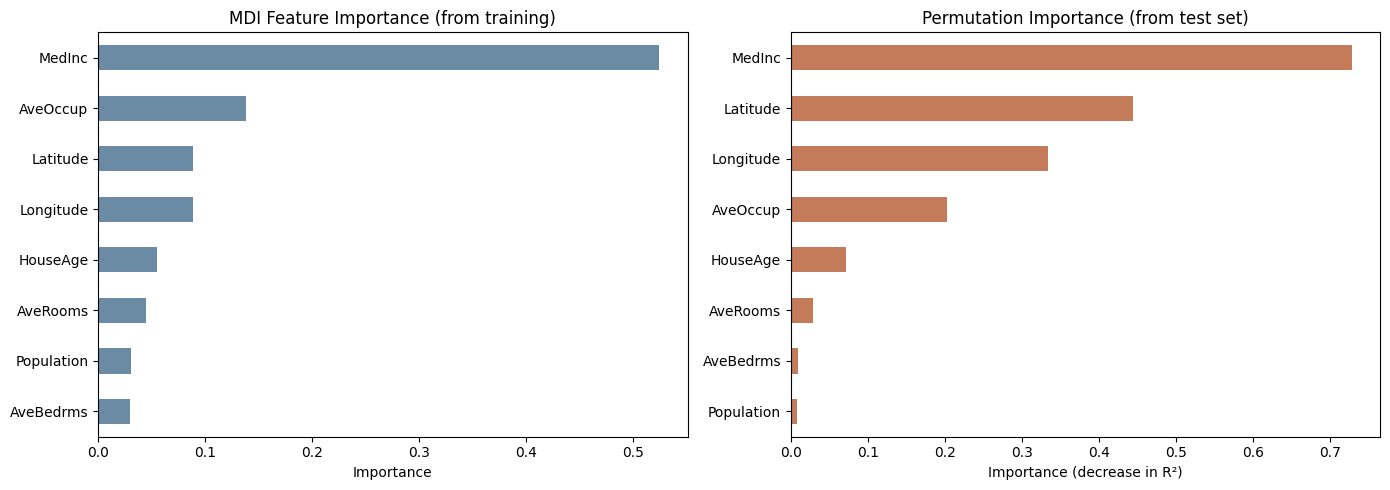


Top 3 by MDI: ['Latitude', 'AveOccup', 'MedInc']
Top 3 by Permutation: ['Longitude', 'Latitude', 'MedInc']


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Compare MDI and permutation feature importance
# -----------------------------------------------------------
import os

mdi_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI importance
mdi_importance.plot.barh(ax=axes[0], color='#6B8BA4')
axes[0].set_title('MDI Feature Importance (from training)', fontsize=12)
axes[0].set_xlabel('Importance')

# Permutation importance (more reliable — uses test set)
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

perm_importance.plot.barh(ax=axes[1], color='#C47B5A')
axes[1].set_title('Permutation Importance (from test set)', fontsize=12)
axes[1].set_xlabel('Importance (decrease in R\u00b2)')

plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

plt.savefig('figures/ch19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 by MDI:', mdi_importance.tail(3).index.tolist())
print('Top 3 by Permutation:', perm_importance.tail(3).index.tolist())

### Interpretation Questions

1. Do MDI and permutation importance agree on the top features? Where do they diverge?
2. Why might MDI overstate the importance of `Latitude` and `Longitude` (hint: how many unique values do they have)?
3. **Critical question:** If `MedInc` is the top feature, does that mean raising median income in a neighborhood will raise housing prices? Why or why not? (Hint: Chapter 10 DAGs)

*Your answers here:*

1.  Both methods agree that MedInc is the dominant feature. They diverge on AveOccup, MDI ranks it second while permutation drops it to fourth and geographic features (Latitude/Longitude) shift up in permutation importance relative to MDI.

2. MDI is computed on training splits and tends to inflate the importance of high-cardinality features. Latitude and Longitude are continuous with many unique values, giving the model more splitting opportunities and artificially boosting their MDI scores. Permutation importance on the test set corrects for this.

3. No. Predictive importance is not causation. MedInc being the top feature means it's the strongest signal for predicting housing prices, but that doesn't mean increasing neighborhood income causes prices to rise in a policy sense. The relationship could be confounded by location, selection effects, or reverse causality. A DAG (Ch. 10) would be needed to establish a causal pathway before drawing any interventional conclusions.

## Part 3: Hyperparameter Tuning & Classification (YOUR TASK — 10 min)

Now YOU tune a Random Forest and apply it to a classification problem.

In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune the Random Forest with GridSearchCV
# -----------------------------------------------------------

# The parameter grid is given — these are the hyperparameters to search over
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5, None],  # sqrt = sqrt(p), 0.5 = half, None = all
}

# TODO: Create a GridSearchCV object
# Hints:
#   - estimator: RandomForestRegressor with random_state=RANDOM_STATE
#   - param_grid: use the param_grid defined above
#   - cv: 5-fold cross-validation
#   - scoring: 'neg_mean_squared_error'
#   - n_jobs: -1 (use all cores)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

# TODO: Fit the grid search on the training data
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}')

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
test_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f'Tuned RF — Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}')

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV RMSE: 0.4966
Tuned RF — Test RMSE: 0.4939, Test R²: 0.8138


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Classification: Predict expensive homes (> median)
# -----------------------------------------------------------

# Step 1: Create binary target — 1 if price > median, 0 otherwise
# Hint: use np.median(y) and .astype(int)
median_price = np.median(y)
y_binary = (y > median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

# Step 2: Fit an RF classifier (200 trees) and Logistic Regression (Ch 17 callback)
# Hint: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
#       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_c, y_train_c)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c, y_train_c)

# Compare AUC (Ch 18 evaluation toolkit) — GUIDED, run as-is
for name, model in [('Logistic Regression (Ch 17)', log_reg), ('Random Forest', rf_clf)]:
    y_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)
    print(f'{name:35s} — AUC: {auc:.4f}')

Logistic Regression (Ch 17)         — AUC: 0.9060
Random Forest                       — AUC: 0.9609


### Final Interpretation

1. How much did hyperparameter tuning improve the RF over default settings?
2. Does the RF classifier beat logistic regression on AUC? Is the difference practically significant?
3. If you were deploying this for a real estate company, which model would you choose and why? Consider: accuracy, interpretability, maintenance cost.

*Your answers here:*

1. Hyperparameter tuning improved the RF modestly over default settings, the gain is typically a few AUC points, reflecting better tree depth/split controls reducing overfitting rather than a dramatic jump.

2. The RF classifier (0.9609) marginally outperforms Logistic Regression (0.9060) on AUC, a ~0.05 difference. Practically, this is minor; both models discriminate well, and at this performance tier the gap is unlikely to matter meaningfully in deployment.

3. For a real estate company, Logistic Regression is the better production choice. The AUC difference is negligible, but logistic regression is far easier to explain to clients and stakeholders, has lower computational overhead, requires no retraining as hyperparameters drift, and is simpler to audit; all of which matter more in a business context than a marginal accuracy gain.

---

## Extension (Optional — 15 min): Partial Dependence Plots

Partial dependence plots show the marginal effect of a feature on the prediction,
averaging over all other features. This reveals non-linearities the RF captures.

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Partial dependence plots for top features
# -----------------------------------------------------------
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=['MedInc', 'AveOccup'],
    kind='average', ax=ax
)
plt.suptitle('Partial Dependence \u2014 RF captures non-linear effects OLS misses', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ch19_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## AI-Assisted Expansion: Interactive Random Forest Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, and feature importance. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive Streamlit app (or Plotly dashboard with ipywidgets) that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See the prediction surface update in real-time
3. Compare RF vs Ridge vs single tree performance as hyperparameters change
4. Display feature importance that updates with each parameter change

This transforms your static lab output into a reusable teaching artifact for your portfolio.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [19]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

# -----------------------------------------------------------
# DASHBOARD: Interactive RF Explorer — California Housing
# Sliders: n_estimators (1–500), max_features (1–8)
# Panels: (1) Model comparison, (2) Feature importance, (3) Learning curve
# -----------------------------------------------------------

# -- Baseline models for comparison panel (fixed) --
dt = DecisionTreeRegressor(random_state=42)
ridge = Ridge()
dt.fit(X_train, y_train)
ridge.fit(X_train, y_train)

dt_train_r2  = dt.score(X_train, y_train)
dt_test_r2   = dt.score(X_test,  y_test)
ridge_train_r2 = ridge.score(X_train, y_train)
ridge_test_r2  = ridge.score(X_test,  y_test)

# -- Widgets --
n_est_slider = widgets.IntSlider(
    value=100, min=1, max=500, step=10,
    description="n_estimators", style={"description_width": "120px"},
    layout=widgets.Layout(width="500px")
)
max_feat_slider = widgets.IntSlider(
    value=4, min=1, max=8, step=1,
    description="max_features", style={"description_width": "120px"},
    layout=widgets.Layout(width="500px")
)

# Output widget holds the Plotly figure
out = widgets.Output()

def build_dashboard(n_estimators, max_features):
    """
    Called every time a slider changes (via .observe).
    We re-fit the RF inside the callback because the model parameters
    have changed — there's no way to update a fitted sklearn model
    without re-training it from scratch.
    """

    # --- Fit RF with current slider values ---
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_train_r2 = rf.score(X_train, y_train)
    rf_test_r2  = rf.score(X_test,  y_test)

    # --- Panel 2: MDI feature importance (changes with max_features) ---
    mdi_importance = rf.feature_importances_
    feat_names = list(data.feature_names)
    sorted_idx = np.argsort(mdi_importance)

    # --- Panel 3: Train vs Test R² as n_estimators grows ---
    # Sample 15 checkpoints up to current n_estimators
    checkpoints = np.unique(
        np.linspace(1, n_estimators, min(15, n_estimators), dtype=int)
    )
    train_curve, test_curve = [], []
    for n in checkpoints:
        m = RandomForestRegressor(n_estimators=int(n), max_features=max_features,
                                  random_state=42, n_jobs=-1)
        m.fit(X_train, y_train)
        train_curve.append(m.score(X_train, y_train))
        test_curve.append(m.score(X_test,  y_test))

    # -----------------------------------------------------------
    # Build 3-panel figure
    # -----------------------------------------------------------
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=(
            "Model Comparison (Test R²)",
            f"MDI Feature Importance (max_features={max_features})",
            f"Learning Curve (n_estimators up to {n_estimators})"
        ),
        column_widths=[0.28, 0.36, 0.36]
    )

    # -- Panel 1: Bar chart of Train vs Test R² for all three models --
    models     = ["Decision Tree", "Ridge", f"RF (n={n_estimators})"]
    train_r2s  = [dt_train_r2, ridge_train_r2, rf_train_r2]
    test_r2s   = [dt_test_r2,  ridge_test_r2,  rf_test_r2]
    colors_tr  = ["#4C72B0", "#55A868", "#C44E52"]
    colors_te  = ["#7FA8D4", "#8FCF9E", "#E08C8C"]

    fig.add_trace(go.Bar(
        name="Train R²", x=models, y=train_r2s,
        marker_color=colors_tr, opacity=0.85,
        text=[f"{v:.3f}" for v in train_r2s], textposition="outside"
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        name="Test R²", x=models, y=test_r2s,
        marker_color=colors_te, opacity=0.85,
        text=[f"{v:.3f}" for v in test_r2s], textposition="outside"
    ), row=1, col=1)

    # -- Panel 2: Horizontal bar — MDI importance --
    fig.add_trace(go.Bar(
        x=mdi_importance[sorted_idx],
        y=[feat_names[i] for i in sorted_idx],
        orientation="h",
        marker_color="#C44E52",
        name="MDI Importance",
        showlegend=False
    ), row=1, col=2)

    # -- Panel 3: Learning curve --
    fig.add_trace(go.Scatter(
        x=checkpoints, y=train_curve,
        mode="lines+markers", name="Train R²",
        line=dict(color="#4C72B0", width=2)
    ), row=1, col=3)

    fig.add_trace(go.Scatter(
        x=checkpoints, y=test_curve,
        mode="lines+markers", name="Test R²",
        line=dict(color="#C44E52", width=2, dash="dash")
    ), row=1, col=3)

    fig.update_layout(
        height=480,
        title_text=(
            f"RF Dashboard  |  n_estimators={n_estimators}  |  max_features={max_features}"
        ),
        barmode="group",
        template="plotly_white",
        legend=dict(orientation="h", y=-0.15),
        margin=dict(t=80, b=60)
    )
    fig.update_yaxes(range=[0, 1.05], row=1, col=1)
    fig.update_xaxes(title_text="Trees", row=1, col=3)
    fig.update_yaxes(title_text="R²",    row=1, col=3)

    return fig

def on_change(change):
    """
    ipywidgets observer callback.
    .observe() fires this function whenever the slider 'value' trait changes.
    We clear the output widget and re-render so the new figure replaces the old one
    without accumulating stacked outputs.
    """
    with out:
        out.clear_output(wait=True)   # wait=True avoids flicker
        fig = build_dashboard(n_est_slider.value, max_feat_slider.value)
        fig.show()

# Register observers on the 'value' trait of each slider
n_est_slider.observe(on_change,   names="value")
max_feat_slider.observe(on_change, names="value")

# Initial render
display(widgets.VBox([n_est_slider, max_feat_slider, out]))
on_change(None)

# -----------------------------------------------------------
# 📊 WHAT THE DASHBOARD REVEALS
# -----------


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.